# Статистический анализ лингвистической разметки заголовков
**Данные:** протокол_разметки.xlsx  
Русский сегмент — 100 заголовков (Pinterest), Китайский — 100 заголовков (小红书)  
**Метрики:** абсолютные частоты, %, IPM (instances per million tokens)  
**Тесты:** корреляция Спирмена (по IPM), U-критерий Манна–Уитни (нормировка по токенам),  
поправка на множественное сравнение — метод Беньямини–Хохберга (FDR)

In [161]:
# Загрузка файла в Colab
from google.colab import files
uploaded = files.upload()  # загрузите протокол_разметки.xlsx

Saving протокол_разметки2.xlsx to протокол_разметки2.xlsx


In [162]:
# Установка jieba (если не установлен)
import subprocess
subprocess.run(['pip', 'install', 'jieba', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, warnings
import jieba
from scipy.stats import spearmanr, mannwhitneyu
from statsmodels.stats.multitest import multipletests

jieba.setLogLevel(20)  # отключить служебные сообщения

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
})
COLORS = {'RU': 'steelblue', 'ZH': 'crimson'}
N = 100

In [163]:
FILENAME = 'протокол_разметки2.xlsx'

df_raw = pd.read_excel(FILENAME, sheet_name='Протокол разметки', header=2)
df_morph = pd.read_excel(FILENAME, sheet_name='Морфологическая разметка')

# Все бинарные признаки: '+' → 1, пусто → 0
df = df_raw.replace('+', 1)
for col in df.columns[9:]:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df_ru = df[df['язык заголовка (RU/ZH) '] == 'RU'].copy()
df_zh = df[df['язык заголовка (RU/ZH) '] == 'ZH'].copy()

print(f'Русский сегмент: {len(df_ru)} заголовков')
print(f'Китайский сегмент: {len(df_zh)} заголовков')
print(f'Всего признаков: {len(df.columns) - 9}')

Русский сегмент: 100 заголовков
Китайский сегмент: 100 заголовков
Всего признаков: 89


## Подсчёт токенов
**Русский:** токен = слово (пробельная разбивка).  
**Китайский:** токен = слово по сегментатору **jieba** (точная разбивка на слова, не иероглифы).  
jieba учитывает, что один иероглиф ≠ одно слово: 深圳龙岗 → ['深圳', '龙岗'] (2 слова из 4 иероглифов).  
Это даёт сопоставимые средние длины заголовков: RU ≈ 8,8 слова, ZH ≈ 10,7 слова.  
Суммарное число токенов — знаменатель для IPM.

In [164]:
TEXT_COL = 'текст\nзаголовка'

def count_ru_tokens(text):
    """Слова для русского (пробельная разбивка)."""
    if not isinstance(text, str): return 1
    tokens = [w for w in re.split(r'\s+', text.strip()) if w]
    return max(len(tokens), 1)

def count_zh_tokens(text):
    """Слова для китайского через jieba (точная сегментация).
    jieba разбивает 深圳龙岗 → ['深圳','龙岗'] (2 слова, не 4 иероглифа).
    """
    if not isinstance(text, str): return 1
    tokens = [t for t in jieba.cut(str(text)) if t.strip()]
    return max(len(tokens), 1)

df_ru['tokens'] = df_ru[TEXT_COL].apply(count_ru_tokens)
df_zh['tokens'] = df_zh[TEXT_COL].apply(count_zh_tokens)

TOTAL_TOKENS_RU = int(df_ru['tokens'].sum())
TOTAL_TOKENS_ZH = int(df_zh['tokens'].sum())

print(f'Метод токенизации: RU — слова (пробелы), ZH — слова (jieba)')
print(f'Суммарно токенов — RU: {TOTAL_TOKENS_RU:,}  |  ZH: {TOTAL_TOKENS_ZH:,}')
print(f'Средняя длина заголовка — RU: {df_ru["tokens"].mean():.1f} сл.'
      f'  |  ZH: {df_zh["tokens"].mean():.1f} сл.')
print()
print('Примеры токенизации (RU):')
for _, row in df_ru.head(3).iterrows():
    print(f'  [{row["tokens"]:2d}] {str(row[TEXT_COL])[:65]}')
print()
print('Примеры токенизации (ZH, jieba):')
for _, row in df_zh.head(3).iterrows():
    text = str(row[TEXT_COL])
    toks = [t for t in jieba.cut(text) if t.strip()]
    print(f'  [{row["tokens"]:2d}] {text[:45]}')
    print(f'       → {toks[:8]}{"..." if len(toks) > 8 else ""}')

Суммарно токенов — RU: 885  |  ZH: 1,435
Средняя длина заголовка — RU: 8.8 сл.  |  ZH: 14.3 иер.

Примеры (RU):
  [13] От чего зависят семейные и брачные традиции❓ Рассказываю про лини
  [ 9] Твоя жизнь — твой уникальный стиль. Сотвори его смело.
  [17] настоящее место или трон блудницы в мозге: вот почему женский обр
Примеры (ZH):
  [19] 深圳龙岗万科新开一家超级实惠的零食店啦！
  [15] 深圳美食|酸菜鱼和川菜1997年至今爆火🌶
  [16] 真香❗️1688探店预告反季皮毛一体小香外套


In [165]:
# Глобальный список для BH-коррекции
ALL_MW_RESULTS = []

def add_labels(bars, ax=None):
    ax = ax or plt.gca()
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f'{h:.0f}', ha='center', va='bottom', fontsize=8)

def freq_table(df_r, df_c, cols, n=100):
    """Абсолютные частоты, % и IPM."""
    rows = []
    for col in cols:
        abs_r = int(df_r[col].sum())
        abs_c = int(df_c[col].sum())
        rows.append({
            'Признак':    col.replace('\n', ' ').strip(),
            'Абс. RU':    abs_r,
            'Отн. RU, %': round(abs_r / n * 100, 1),
            'IPM RU':     round(abs_r / TOTAL_TOKENS_RU * 1_000_000, 1),
            'Абс. ZH':    abs_c,
            'Отн. ZH, %': round(abs_c / n * 100, 1),
            'IPM ZH':     round(abs_c / TOTAL_TOKENS_ZH * 1_000_000, 1),
        })
    return pd.DataFrame(rows)

def ipm_vectors(df_r, df_c, cols):
    r = np.array([df_r[c].sum() / TOTAL_TOKENS_RU * 1_000_000 for c in cols])
    c = np.array([df_c[c].sum() / TOTAL_TOKENS_ZH * 1_000_000 for c in cols])
    return r, c

def bar_chart(r_vals, zh_vals, labels, title,
              ylabel='IPM (instances per million tokens)', figsize=(13, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(labels))
    w = 0.38
    b_ru = ax.bar(x - w/2, r_vals, w, label='Русский сегмент', color=COLORS['RU'])
    b_zh = ax.bar(x + w/2, zh_vals, w, label='Китайский сегмент', color=COLORS['ZH'])
    add_labels(b_ru, ax); add_labels(b_zh, ax)
    ax.set_xticks(x)
    ax.set_xticklabels([l.replace('\n', ' ').strip() for l in labels],
                       rotation=40, ha='right', fontsize=9)
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

def spearman_block(r_ipm, zh_ipm, block_name):
    corr, p = spearmanr(r_ipm, zh_ipm)
    sig = '✓ значима' if p < 0.05 else '✗ незначима'
    print(f'Спирмен [{block_name}]:  r = {corr:.3f},  p = {p:.4f}  → {sig}')
    return corr, p

def mannwhitney_block(df_r, df_c, cols, block_name):
    """U-критерий по нормированным на токены значениям.
    Все результаты накапливаются в ALL_MW_RESULTS для BH-коррекции."""
    print(f'\n─── U-критерий Манна–Уитни: {block_name} ───')
    results = []
    for col in cols:
        r_tok = df_r['tokens'].values.astype(float)
        c_tok = df_c['tokens'].values.astype(float)
        r_data = df_r[col].values.astype(float) / r_tok
        c_data = df_c[col].values.astype(float) / c_tok
        if r_data.sum() == 0 and c_data.sum() == 0:
            continue
        stat, p = mannwhitneyu(r_data, c_data, alternative='two-sided')
        clean = col.replace('\n', ' ').strip()
        entry = {'Блок': block_name, 'Признак': clean,
                 'U': round(stat, 1), 'p-value (raw)': round(p, 6)}
        results.append(entry)
        ALL_MW_RESULTS.append(entry.copy())
    res_df = pd.DataFrame(results)
    if not res_df.empty:
        res_df['Значимость'] = res_df['p-value (raw)'].apply(
            lambda v: '**p < 0.05**' if v < 0.05 else 'p ≥ 0.05')
        display(res_df[['Признак','U','p-value (raw)','Значимость']].style.applymap(
            lambda v: 'font-weight:bold; color:darkred' if '**' in str(v) else '',
            subset=['Значимость']))
    return res_df

def plot_block_scatter(r_ipm, zh_ipm, labels, block_name):
    r_ipm  = np.array(r_ipm,  dtype=float)
    zh_ipm = np.array(zh_ipm, dtype=float)
    if r_ipm.sum() == 0 and zh_ipm.sum() == 0:
        print(f'[{block_name}] — все значения нулевые, график пропущен.')
        return
    corr, p_val = spearmanr(r_ipm, zh_ipm)
    sig = '✓ значима' if p_val < 0.05 else '✗ незначима'
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))
    for i, (x, y, lbl) in enumerate(zip(r_ipm, zh_ipm, labels)):
        ax.scatter(x, y, s=90, color=colors[i], zorder=3,
                   edgecolors='white', linewidths=0.6)
        ax.annotate(lbl.replace('\n', ' ').strip(), (x, y),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color='dimgray')
    if len(set(r_ipm)) > 1:
        m, b_c = np.polyfit(r_ipm, zh_ipm, 1)
        xl = np.linspace(r_ipm.min(), r_ipm.max(), 200)
        ax.plot(xl, m*xl + b_c, color='red', lw=1.5, linestyle='--',
                label='Линия тренда', zorder=2)
    ax.set_xlabel('Русский сегмент (IPM)', fontsize=10)
    ax.set_ylabel('Китайский сегмент (IPM)', fontsize=10)
    ax.set_title(f'Корреляция (IPM): {block_name}', fontsize=12, pad=12)
    ax.text(0.03, 0.95, f'Спирмен r = {corr:.3f}\np = {p_val:.4f}  {sig}',
            transform=ax.transAxes,
            bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.85),
            fontsize=9, verticalalignment='top')
    if len(set(r_ipm)) > 1:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## О применяемых статистических критериях

### IPM (instances per million tokens)
**(кол-во заголовков с признаком / суммарное кол-во токенов) × 1 000 000**.  
**Русский** — токен = слово (пробельная токенизация).  
**Китайский** — токен = иероглиф CJK (стандарт корпусной синологии).  

### Корреляция Спирмена
Вычисляется по **IPM-векторам** блока. Отвечает: *похож ли профиль признаков RU и ZH с учётом длины заголовков?*

### U-критерий Манна–Уитни
Наблюдение = `признак_i / токены_i` (нормированная плотность на заголовок).  
Учитывает длину заголовка как ковариату.

### Поправка Беньямини–Хохберга (FDR)
Все p-значения из всех тестов Манна–Уитни корректируются **совместно**.  
Контролирует долю ложно значимых результатов на уровне 5% (q = 0.05).  
Итоговая таблица — в конце ноутбука.

---
## Блок 1. Графический / орфографический уровень
### 1.1 Графика и 1.2 Пунктуация

In [166]:
b1_graphic = [
    'повтор букв',
    'сочетание строчных и прописных букв',
    'капитализация текста',
]
b1_punct = [
    'наличие восклицательных знаков',
    'повтор восклицательных знаков',
    'наличие вопросительных знаков',
    'повтор вопросительных знаков',
    'многоточие',
]
b1_all = b1_graphic + b1_punct

ft1 = freq_table(df_ru, df_zh, b1_all)
print('=== Блок 1.1–1.2: Графика и пунктуация ===')
display(ft1)

=== Блок 1.1–1.2: Графика и пунктуация ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,повтор букв,0,0.0,0.0,0,0.0,0.0
1,сочетание строчных и прописных букв,6,6.0,6779.7,3,3.0,2090.6
2,капитализация текста,2,2.0,2259.9,7,7.0,4878.0
3,наличие восклицательных знаков,7,7.0,7909.6,28,28.0,19512.2
4,повтор восклицательных знаков,0,0.0,0.0,9,9.0,6271.8
5,наличие вопросительных знаков,9,9.0,10169.5,8,8.0,5574.9
6,повтор вопросительных знаков,0,0.0,0.0,0,0.0,0.0
7,многоточие,0,0.0,0.0,2,2.0,1393.7


In [167]:
r1, c1 = ipm_vectors(df_ru, df_zh, b1_all)
spearman_block(r1, c1, 'Блок 1.1–1.2 Графика + Пунктуация')
mannwhitney_block(df_ru, df_zh, b1_all, 'Блок 1.1–1.2 Графика + Пунктуация');

Спирмен [Блок 1.1–1.2 Графика + Пунктуация]:  r = 0.600,  p = 0.1161  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 1.1–1.2 Графика + Пунктуация ───


,Признак,U,p-value (raw),Значимость
0,сочетание строчных и прописных букв,5155.000000,0.293261,p ≥ 0.05
1,капитализация текста,4753.000000,0.093570,p ≥ 0.05
2,наличие восклицательных знаков,4009.000000,0.000257,**p < 0.05**
3,повтор восклицательных знаков,4550.000000,0.002230,**p < 0.05**
4,наличие вопросительных знаков,5077.000000,0.699153,p ≥ 0.05
5,многоточие,4900.000000,0.158341,p ≥ 0.05


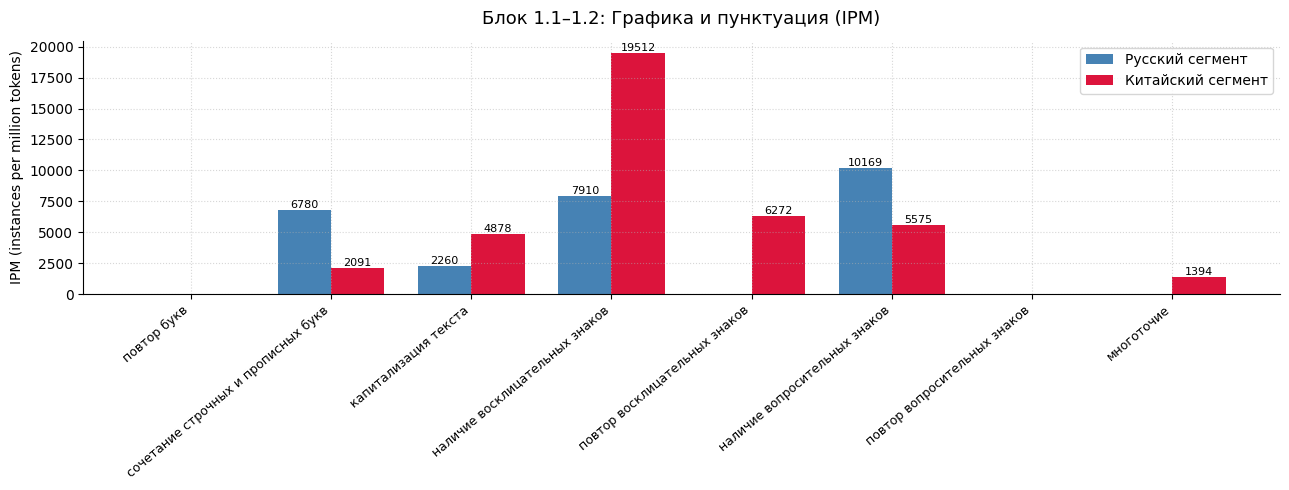

In [168]:
bar_chart(r1, c1, b1_all, 'Блок 1.1–1.2: Графика и пунктуация (IPM)')

### 1.3 Эмотиконы

In [169]:
b1_emoji = [
    'наличие эмодзи',
    'номинативная функция',
    'коммуникативная функция\nэмодзи',
    'оценочная функция',
    'эмоционально-экспрессивная функция',
    'реактивная функия',
    'модальная функция',
    'разделительная функция',
]
ft_emoji = freq_table(df_ru, df_zh, b1_emoji)
print('=== Блок 1.3: Эмотиконы ===')
display(ft_emoji)

=== Блок 1.3: Эмотиконы ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,наличие эмодзи,28,28.0,31638.4,47,47.0,32752.6
1,номинативная функция,7,7.0,7909.6,11,11.0,7665.5
2,коммуникативная функция эмодзи,3,3.0,3389.8,0,0.0,0.0
3,оценочная функция,3,3.0,3389.8,11,11.0,7665.5
4,эмоционально-экспрессивная функция,11,11.0,12429.4,11,11.0,7665.5
5,реактивная функия,0,0.0,0.0,1,1.0,696.9
6,модальная функция,3,3.0,3389.8,0,0.0,0.0
7,разделительная функция,14,14.0,15819.2,40,40.0,27874.6


In [170]:
r_emoji, c_emoji = ipm_vectors(df_ru, df_zh, b1_emoji)
spearman_block(r_emoji, c_emoji, 'Блок 1.3 Эмотиконы')
mannwhitney_block(df_ru, df_zh, b1_emoji, 'Блок 1.3 Эмотиконы');

Спирмен [Блок 1.3 Эмотиконы]:  r = 0.830,  p = 0.0107  → ✓ значима

─── U-критерий Манна–Уитни: Блок 1.3 Эмотиконы ───


,Признак,U,p-value (raw),Значимость
0,наличие эмодзи,4545.000000,0.201371,p ≥ 0.05
1,номинативная функция,4821.500000,0.380961,p ≥ 0.05
2,коммуникативная функция эмодзи,5150.000000,0.082748,p ≥ 0.05
3,оценочная функция,4604.000000,0.028899,**p < 0.05**
4,эмоционально-экспрессивная функция,5052.500000,0.815046,p ≥ 0.05
5,реактивная функия,4950.000000,0.322174,p ≥ 0.05
6,модальная функция,5150.000000,0.082745,p ≥ 0.05
7,разделительная функция,3853.500000,0.000340,**p < 0.05**


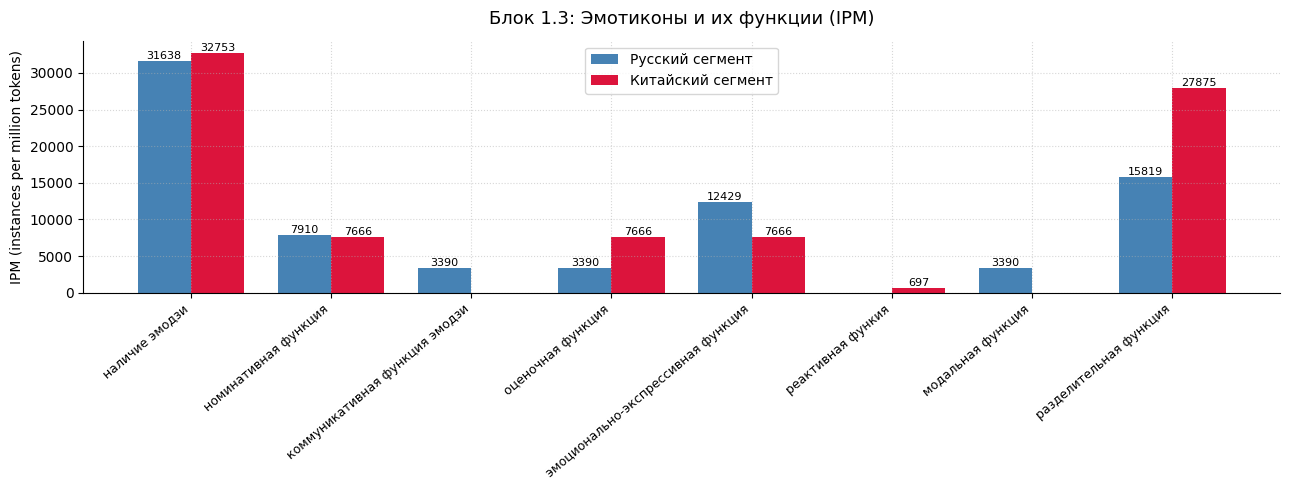

In [171]:
bar_chart(r_emoji, c_emoji, b1_emoji, 'Блок 1.3: Эмотиконы и их функции (IPM)')

### 1.4 Хэштеги и 1.5 Смешение кодов

In [172]:
b1_codes = [
    'наличие хэштегов',
    'математические знаки',
    'использование цифр',
    'форма вида   n X-ов',
    'форма вида   n Y-x X-ов',
    'форма вида   n X-ов, которые..',
    # 'цифровые созвучия' — отсутствует в данном файле разметки
    'буквенно-цифровые комбинации',
    'комбинации цифр и иероглифов',
    'буквенно-иероглифические комбинации',
    'буквенно-символьные комбинации',
    'сочетание иероглифов и английских слов',
    'буквенно-иероглифически-цифровые комбинации',
]
ft_codes = freq_table(df_ru, df_zh, b1_codes)
print('=== Блок 1.4–1.5: Смешение кодов ===')
display(ft_codes)

=== Блок 1.4–1.5: Смешение кодов ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,наличие хэштегов,0,0.0,0.0,0,0.0,0.0
1,математические знаки,1,1.0,1129.9,3,3.0,2090.6
2,использование цифр,28,28.0,31638.4,24,24.0,16724.7
3,форма вида n X-ов,10,10.0,11299.4,4,4.0,2787.5
4,форма вида n Y-x X-ов,10,10.0,11299.4,1,1.0,696.9
5,"форма вида n X-ов, которые..",8,8.0,9039.5,0,0.0,0.0
6,буквенно-цифровые комбинации,0,0.0,0.0,0,0.0,0.0
7,комбинации цифр и иероглифов,0,0.0,0.0,1,1.0,696.9
8,буквенно-иероглифические комбинации,0,0.0,0.0,3,3.0,2090.6
9,буквенно-символьные комбинации,0,0.0,0.0,0,0.0,0.0


In [173]:
r_codes, c_codes = ipm_vectors(df_ru, df_zh, b1_codes)
spearman_block(r_codes, c_codes, 'Блок 1.4–1.5 Смешение кодов')
mannwhitney_block(df_ru, df_zh, b1_codes, 'Блок 1.4–1.5 Смешение кодов');

Спирмен [Блок 1.4–1.5 Смешение кодов]:  r = 0.466,  p = 0.1271  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 1.4–1.5 Смешение кодов ───


,Признак,U,p-value (raw),Значимость
0,математические знаки,4901.500000,0.323439,p ≥ 0.05
1,использование цифр,5424.000000,0.179630,p ≥ 0.05
2,форма вида n X-ов,5308.000000,0.089385,p ≥ 0.05
3,форма вида n Y-x X-ов,5455.000000,0.004941,**p < 0.05**
4,"форма вида n X-ов, которые..",5400.000000,0.004037,**p < 0.05**
5,комбинации цифр и иероглифов,4950.000000,0.322174,p ≥ 0.05
6,буквенно-иероглифические комбинации,4850.000000,0.082748,p ≥ 0.05
7,сочетание иероглифов и английских слов,4650.000000,0.007314,**p < 0.05**


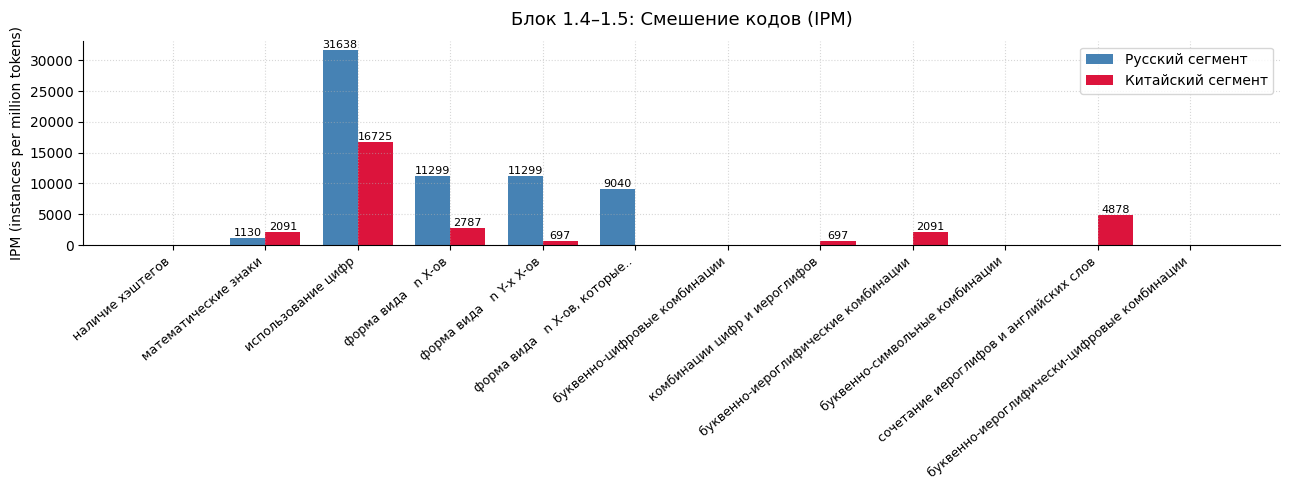

In [174]:
bar_chart(r_codes, c_codes, b1_codes, 'Блок 1.4–1.5: Смешение кодов (IPM)')

---
## Блок 2. Фонетический уровень

In [175]:
b2 = [
    # 'звукоподражания буквами' — отсутствует в данном файле разметки
    'звукоподражания иероглифами',
    'звукоподражания цифрами',
    'цифровые слова-созвучия',
    # 'созвучия на основе заимствований из английского' — отсутствует в данном файле разметки
    'созвучия на основе китайских словосочетаний',
]
ft2 = freq_table(df_ru, df_zh, b2)
print('=== Блок 2: Фонетический уровень ===')
display(ft2)

=== Блок 2: Фонетический уровень ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,звукоподражания иероглифами,0,0.0,0.0,4,4.0,2787.5
1,звукоподражания цифрами,0,0.0,0.0,6554,6554.0,4567247.4
2,цифровые слова-созвучия,0,0.0,0.0,0,0.0,0.0
3,созвучия на основе китайских словосочетаний,0,0.0,0.0,0,0.0,0.0


In [176]:
r2, c2 = ipm_vectors(df_ru, df_zh, b2)
spearman_block(r2, c2, 'Блок 2 Фонетический')
mannwhitney_block(df_ru, df_zh, b2, 'Блок 2 Фонетический');

Спирмен [Блок 2 Фонетический]:  r = nan,  p = nan  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 2 Фонетический ───


,Признак,U,p-value (raw),Значимость
0,звукоподражания иероглифами,4800.000000,0.044423,**p < 0.05**
1,звукоподражания цифрами,4900.000000,0.158341,p ≥ 0.05


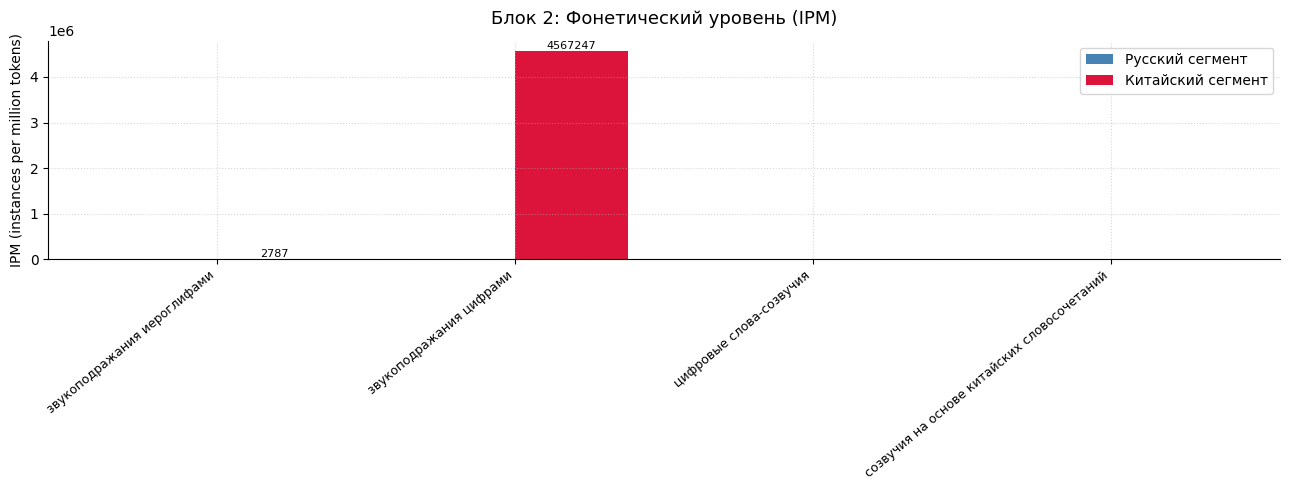

In [177]:
bar_chart(r2, c2, b2, 'Блок 2: Фонетический уровень (IPM)')

---
## Блок 3. Морфологический уровень

In [178]:
df_morph_ru = df_morph[df_morph['language'] == 'русский']
df_morph_zh = df_morph[df_morph['language'] == 'китайский']

ALL_POS = ['NOUN','VERB','ADJ','PROPN','ADV','NUM','PART','ADP','CCONJ','SCONJ','DET','PRON','X']
pos_ru = df_morph_ru['top_pos_en'].value_counts().reindex(ALL_POS, fill_value=0)
pos_zh = df_morph_zh['top_pos_en'].value_counts().reindex(ALL_POS, fill_value=0)
mask = (pos_ru + pos_zh) > 0
pos_ru_f = pos_ru[mask]; pos_zh_f = pos_zh[mask]

POS_RU_NAMES = {'NOUN':'Сущ.','VERB':'Глагол','ADJ':'Прил.','PROPN':'Имя собств.',
                'ADV':'Наречие','NUM':'Числит.','PART':'Частица','X':'X/Прочее'}
pos_labels = [POS_RU_NAMES.get(p, p) for p in pos_ru_f.index]

# Также преобладающая ч.р. доступна в основном листе (колонка 'преобладающая часть речи')
pos_main_ru = df_ru['преобладающая часть речи'].value_counts()
pos_main_zh = df_zh['преобладающая часть речи'].value_counts()

pos_ipm_ru = pos_ru_f.values / TOTAL_TOKENS_RU * 1_000_000
pos_ipm_zh = pos_zh_f.values / TOTAL_TOKENS_ZH * 1_000_000

pos_df = pd.DataFrame({
    'POS': pos_ru_f.index,
    'Назв.': pos_labels,
    'Абс. RU': pos_ru_f.values,
    'IPM RU': pos_ipm_ru.round(1),
    'Абс. ZH': pos_zh_f.values,
    'IPM ZH': pos_ipm_zh.round(1),
})
print('=== Преобладающая часть речи ===')
display(pos_df)

=== Преобладающая часть речи ===


,POS,Назв.,Абс. RU,IPM RU,Абс. ZH,IPM ZH
0,NOUN,Сущ.,86,97175.1,70,48780.5
1,VERB,Глагол,1,1129.9,26,18118.5
2,ADJ,Прил.,9,10169.5,2,1393.7
3,PROPN,Имя собств.,3,3389.8,2,1393.7
4,ADV,Наречие,1,1129.9,0,0.0


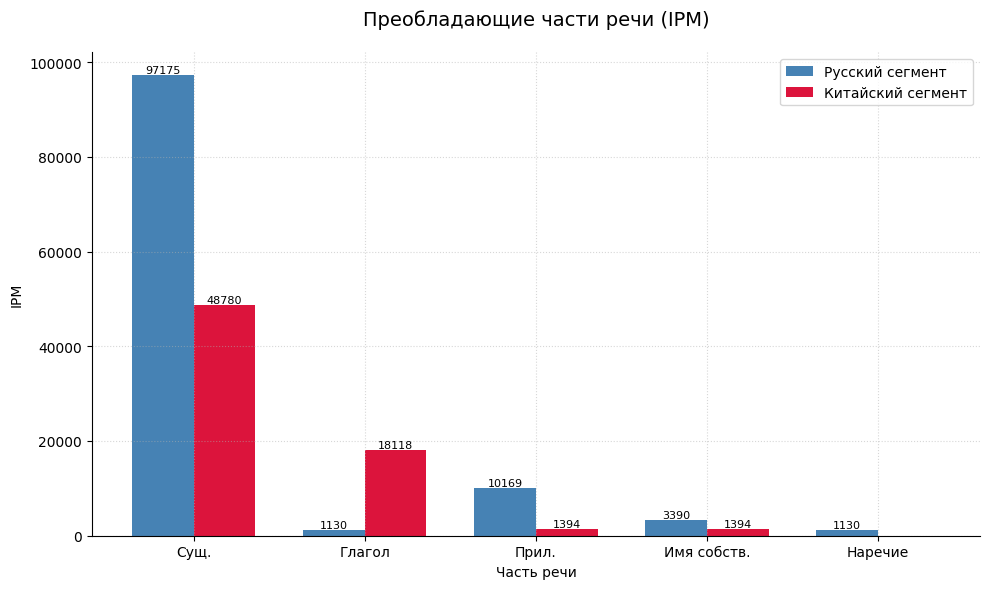

In [179]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pos_labels))
w = 0.36
b_ru_b = ax.bar(x - w/2, pos_ipm_ru, w, label='Русский сегмент', color=COLORS['RU'])
b_zh_b = ax.bar(x + w/2, pos_ipm_zh, w, label='Китайский сегмент', color=COLORS['ZH'])
add_labels(b_ru_b, ax); add_labels(b_zh_b, ax)
ax.set_title('Преобладающие части речи (IPM)', pad=20, fontsize=14)
ax.set_xlabel('Часть речи'); ax.set_ylabel('IPM')
ax.set_xticks(x); ax.set_xticklabels(pos_labels, fontsize=10)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

In [180]:
b3_morph = [
    'модель: имя прилагательное + имя существительное',
    '1 л. ед.ч.\n',
    '1 л. мн.ч.\n',
    'императив\n',
    'превосходная степень\nсравнения       ',
]
for c in b3_morph:
    df_ru[c] = pd.to_numeric(df_ru[c].replace({None: 0}), errors='coerce').fillna(0)
    df_zh[c] = pd.to_numeric(df_zh[c].replace({None: 0}), errors='coerce').fillna(0)

ft3 = freq_table(df_ru, df_zh, b3_morph)
print('=== Блок 3: Морфологические модели ===')
display(ft3)

=== Блок 3: Морфологические модели ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,модель: имя прилагательное + имя существительное,52,52.0,58757.1,19,19.0,13240.4
1,1 л. ед.ч.,3,3.0,3389.8,12,12.0,8362.4
2,1 л. мн.ч.,3,3.0,3389.8,2,2.0,1393.7
3,императив,6,6.0,6779.7,9,9.0,6271.8
4,превосходная степень сравнения,4,4.0,4519.8,3,3.0,2090.6


In [181]:
r3, c3 = ipm_vectors(df_ru, df_zh, b3_morph)
spearman_block(r3, c3, 'Блок 3 Морфология (формы)')
mannwhitney_block(df_ru, df_zh, b3_morph, 'Блок 3 Морфология (формы)');

Спирмен [Блок 3 Морфология (формы)]:  r = 0.564,  p = 0.3217  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 3 Морфология (формы) ───


,Признак,U,p-value (raw),Значимость
0,модель: имя прилагательное + имя существительное,7060.500000,0.000000,**p < 0.05**
1,1 л. ед.ч.,4543.500000,0.014695,**p < 0.05**
2,1 л. мн.ч.,5052.500000,0.638496,p ≥ 0.05
3,императив,4875.500000,0.507036,p ≥ 0.05
4,превосходная степень сравнения,5053.000000,0.687021,p ≥ 0.05


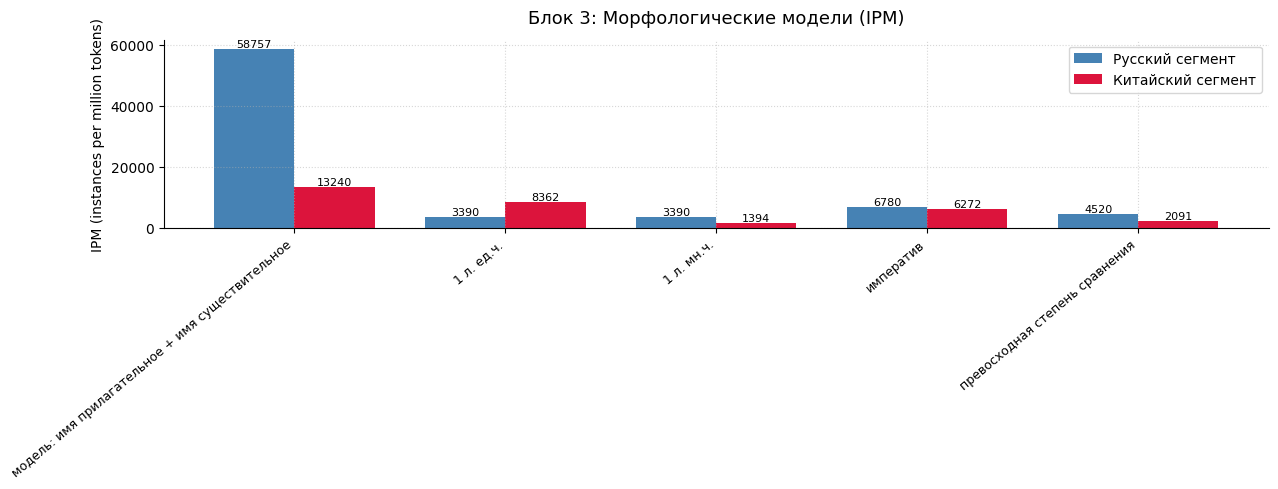

In [182]:
bar_chart(r3, c3, b3_morph, 'Блок 3: Морфологические модели (IPM)')

---
## Блок 4. Лексико-семантический уровень

In [183]:
b4_style = [
    'нейтральная\nлексика',
    'разговорная лексика',
    '\nинтернет-сленг',
    'сленг',
    'жаргонизм',
    'междометие\n',
]
ft4s = freq_table(df_ru, df_zh, b4_style)
print('=== 4.1 Стилистически маркированная лексика ===')
display(ft4s)

=== 4.1 Стилистически маркированная лексика ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,нейтральная лексика,82,82.0,92655.4,36,36.0,25087.1
1,разговорная лексика,12,12.0,13559.3,20,20.0,13937.3
2,интернет-сленг,5,5.0,5649.7,31,31.0,21602.8
3,сленг,2,2.0,2259.9,19,19.0,13240.4
4,жаргонизм,3,3.0,3389.8,4,4.0,2787.5
5,междометие,0,0.0,0.0,10,10.0,6968.6


In [184]:
r4s, c4s = ipm_vectors(df_ru, df_zh, b4_style)
spearman_block(r4s, c4s, 'Блок 4.1 Стилистически маркированная лексика')
mannwhitney_block(df_ru, df_zh, b4_style, 'Блок 4.1 Стилистически маркированная лексика');

Спирмен [Блок 4.1 Стилистически маркированная лексика]:  r = 0.771,  p = 0.0724  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 4.1 Стилистически маркированная лексика ───


,Признак,U,p-value (raw),Значимость
0,нейтральная лексика,8254.500000,0.000000,**p < 0.05**
1,разговорная лексика,4665.500000,0.200968,p ≥ 0.05
2,интернет-сленг,3754.500000,0.000006,**p < 0.05**
3,сленг,4169.000000,0.000137,**p < 0.05**
4,жаргонизм,4956.000000,0.738506,p ≥ 0.05
5,междометие,4500.000000,0.001231,**p < 0.05**


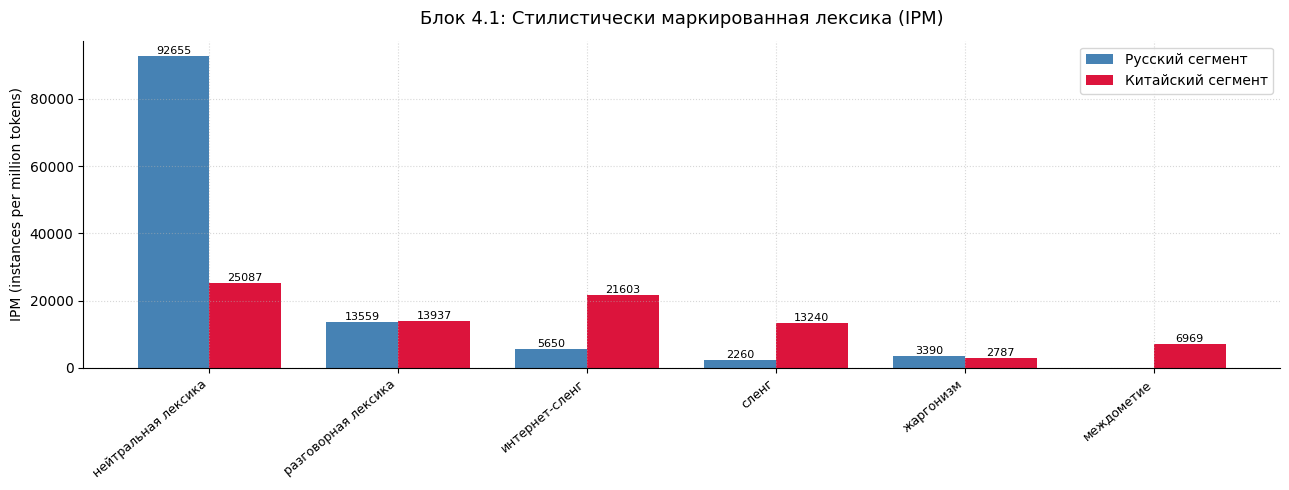

In [185]:
bar_chart(r4s, c4s, b4_style, 'Блок 4.1: Стилистически маркированная лексика (IPM)')

In [186]:
b4_borr = [
    '\nанглицизм\n',
    'фонетические\n',
    'семантические',
    'фонет.-семант.',
    'заимствование-созвучие',
    'неассимилировное заимствование',
]
ft4b = freq_table(df_ru, df_zh, b4_borr)
print('=== 4.2 Заимствования ===')
display(ft4b)

=== 4.2 Заимствования ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,англицизм,30,30.0,33898.3,7,7.0,4878.0
1,фонетические,0,0.0,0.0,5,5.0,3484.3
2,семантические,0,0.0,0.0,4,4.0,2787.5
3,фонет.-семант.,0,0.0,0.0,3,3.0,2090.6
4,заимствование-созвучие,0,0.0,0.0,0,0.0,0.0
5,неассимилировное заимствование,2,2.0,2259.9,15,15.0,10453.0


In [187]:
r4b, c4b = ipm_vectors(df_ru, df_zh, b4_borr)
spearman_block(r4b, c4b, 'Блок 4.2 Заимствования')
mannwhitney_block(df_ru, df_zh, b4_borr, 'Блок 4.2 Заимствования');

Спирмен [Блок 4.2 Заимствования]:  r = 0.778,  p = 0.0687  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 4.2 Заимствования ───


,Признак,U,p-value (raw),Значимость
0,англицизм,6214.000000,0.000012,**p < 0.05**
1,фонетические,4750.000000,0.024188,**p < 0.05**
2,семантические,4800.000000,0.044423,**p < 0.05**
3,фонет.-семант.,4850.000000,0.082748,p ≥ 0.05
4,неассимилировное заимствование,4355.000000,0.001130,**p < 0.05**


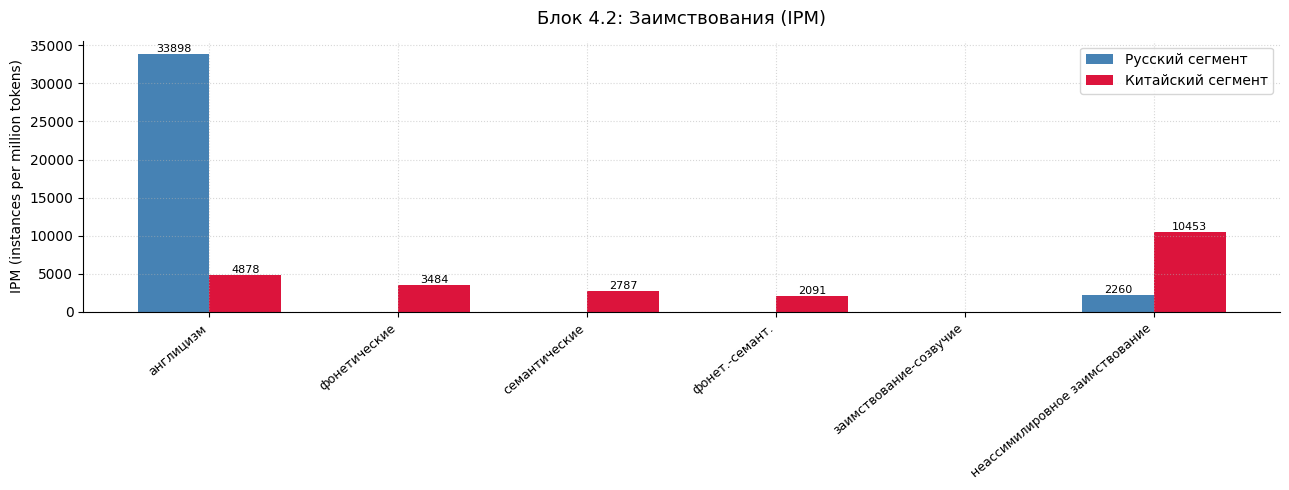

In [188]:
bar_chart(r4b, c4b, b4_borr, 'Блок 4.2: Заимствования (IPM)')

In [189]:
b4_eval = [
    'оценочное прил.',
    # 'превосходная степень прил.' — отсутствует в данном файле разметки
    'интенсифика-\nторы',
    'метафора',
    'гипербола\n',
    'оксюморон\n',
    'фразеологизм /\nидиома',
    'кавычки ',
]
ft4e = freq_table(df_ru, df_zh, b4_eval)
print('=== 4.3 Оценочность ===')
display(ft4e)

=== 4.3 Оценочность ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,оценочное прил.,31,31.0,35028.2,50,50.0,34843.2
1,интенсифика- торы,13,13.0,14689.3,13,13.0,9059.2
2,метафора,10,10.0,11299.4,18,18.0,12543.6
3,гипербола,11,11.0,12429.4,7,7.0,4878.0
4,оксюморон,0,0.0,0.0,0,0.0,0.0
5,фразеологизм / идиома,7,7.0,7909.6,5,5.0,3484.3
6,кавычки,3,3.0,3389.8,0,0.0,0.0


In [190]:
r4e, c4e = ipm_vectors(df_ru, df_zh, b4_eval)
spearman_block(r4e, c4e, 'Блок 4.3 Оценочность')
mannwhitney_block(df_ru, df_zh, b4_eval, 'Блок 4.3 Оценочность');

Спирмен [Блок 4.3 Оценочность]:  r = 0.883,  p = 0.0085  → ✓ значима

─── U-критерий Манна–Уитни: Блок 4.3 Оценочность ───


,Признак,U,p-value (raw),Значимость
0,оценочное прил.,4659.500000,0.349645,p ≥ 0.05
1,интенсифика- торы,5079.000000,0.742738,p ≥ 0.05
2,метафора,4675.000000,0.188741,p ≥ 0.05
3,гипербола,5231.000000,0.256561,p ≥ 0.05
4,фразеологизм / идиома,5106.500000,0.529186,p ≥ 0.05
5,кавычки,5150.000000,0.082748,p ≥ 0.05


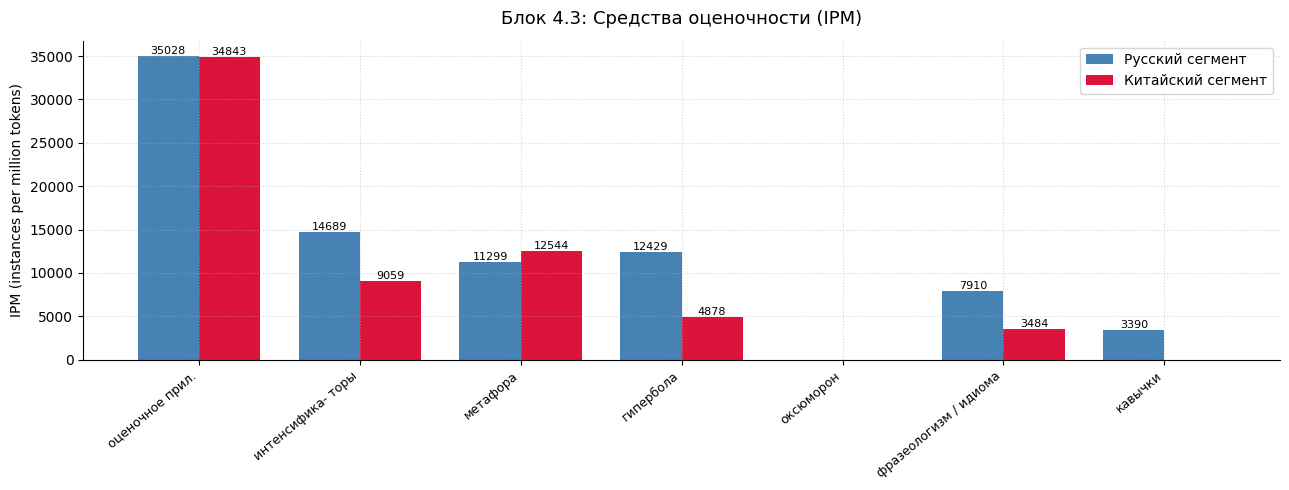

In [191]:
bar_chart(r4e, c4e, b4_eval, 'Блок 4.3: Средства оценочности (IPM)')

In [192]:
b4_add = ['\nнеологизм ', 'аббревиатура']
ft4a = freq_table(df_ru, df_zh, b4_add)
print('=== 4.4 Дополнительная лексика ===')
display(ft4a)
mannwhitney_block(df_ru, df_zh, b4_add, 'Блок 4.4 Доп. лексика');

=== 4.4 Дополнительная лексика ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,неологизм,3,3.0,3389.8,4,4.0,2787.5
1,аббревиатура,6,6.0,6779.7,11,11.0,7665.5



─── U-критерий Манна–Уитни: Блок 4.4 Доп. лексика ───


,Признак,U,p-value (raw),Значимость
0,неологизм,4956.000000,0.738504,p ≥ 0.05
1,аббревиатура,4758.500000,0.223409,p ≥ 0.05


---
## Блок 5. Синтаксический уровень

In [193]:
b5_struct = ['простое','ССП','СПП','БСП','номинативное','неполное']
ft5s = freq_table(df_ru, df_zh, b5_struct)
print('=== 5.1 Тип предложения по структуре ===')
display(ft5s)

=== 5.1 Тип предложения по структуре ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,простое,56,56.0,63276.8,51,51.0,35540.1
1,ССП,2,2.0,2259.9,0,0.0,0.0
2,СПП,17,17.0,19209.0,1,1.0,696.9
3,БСП,25,25.0,28248.6,16,16.0,11149.8
4,номинативное,58,58.0,65536.7,35,35.0,24390.2
5,неполное,7,7.0,7909.6,33,33.0,22996.5


In [194]:
r5s, c5s = ipm_vectors(df_ru, df_zh, b5_struct)
spearman_block(r5s, c5s, 'Блок 5.1 Тип по структуре')
mannwhitney_block(df_ru, df_zh, b5_struct, 'Блок 5.1 Тип предложения по структуре');

Спирмен [Блок 5.1 Тип по структуре]:  r = 0.771,  p = 0.0724  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 5.1 Тип предложения по структуре ───


,Признак,U,p-value (raw),Значимость
0,простое,6223.000000,0.001628,**p < 0.05**
1,ССП,5100.000000,0.158341,p ≥ 0.05
2,СПП,5808.500000,0.000070,**p < 0.05**
3,БСП,5631.500000,0.028821,**p < 0.05**
4,номинативное,6897.000000,0.000000,**p < 0.05**
5,неполное,3746.000000,0.000012,**p < 0.05**


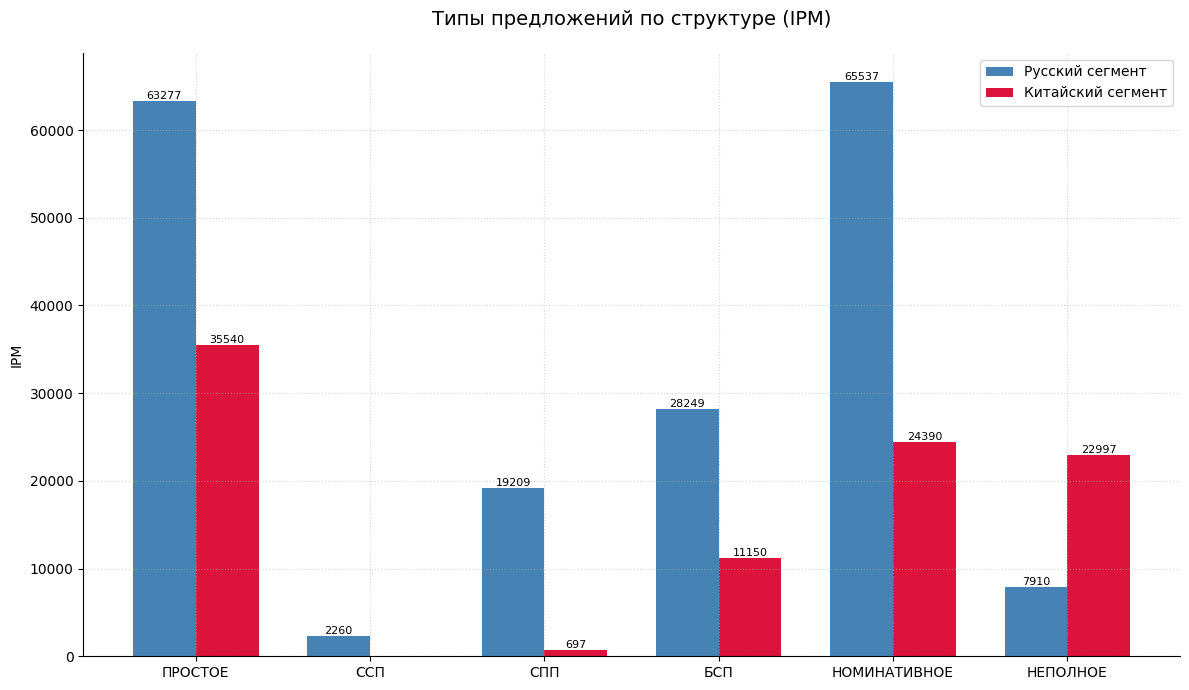

In [195]:
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(b5_struct)); w = 0.36
b_ru_b = ax.bar(x - w/2, r5s, w, label='Русский сегмент', color=COLORS['RU'])
b_zh_b = ax.bar(x + w/2, c5s, w, label='Китайский сегмент', color=COLORS['ZH'])
add_labels(b_ru_b, ax); add_labels(b_zh_b, ax)
ax.set_title('Типы предложений по структуре (IPM)', pad=20, fontsize=14)
ax.set_ylabel('IPM'); ax.set_xticks(x)
ax.set_xticklabels([c.replace('\n','').strip().upper() for c in b5_struct], fontsize=10)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

In [196]:
b5_goal = ['повествовательное .','вопросительное   .','побудительное    .']
ft5g = freq_table(df_ru, df_zh, b5_goal)
print('=== 5.2 Тип предложения по цели ===')
display(ft5g)

=== 5.2 Тип предложения по цели ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,повествовательное .,91,91.0,102824.9,79,79.0,55052.3
1,вопросительное .,9,9.0,10169.5,16,16.0,11149.8
2,побудительное .,6,6.0,6779.7,12,12.0,8362.4


In [197]:
r5g, c5g = ipm_vectors(df_ru, df_zh, b5_goal)
spearman_block(r5g, c5g, 'Блок 5.2 Тип по цели высказывания')
mannwhitney_block(df_ru, df_zh, b5_goal, 'Блок 5.2 Тип предложения по цели');

Спирмен [Блок 5.2 Тип по цели высказывания]:  r = 1.000,  p = 0.0000  → ✓ значима

─── U-критерий Манна–Уитни: Блок 5.2 Тип предложения по цели ───


,Признак,U,p-value (raw),Значимость
0,повествовательное .,7965.500000,0.000000,**p < 0.05**
1,вопросительное .,4711.500000,0.220609,p ≥ 0.05
2,побудительное .,4719.000000,0.167385,p ≥ 0.05


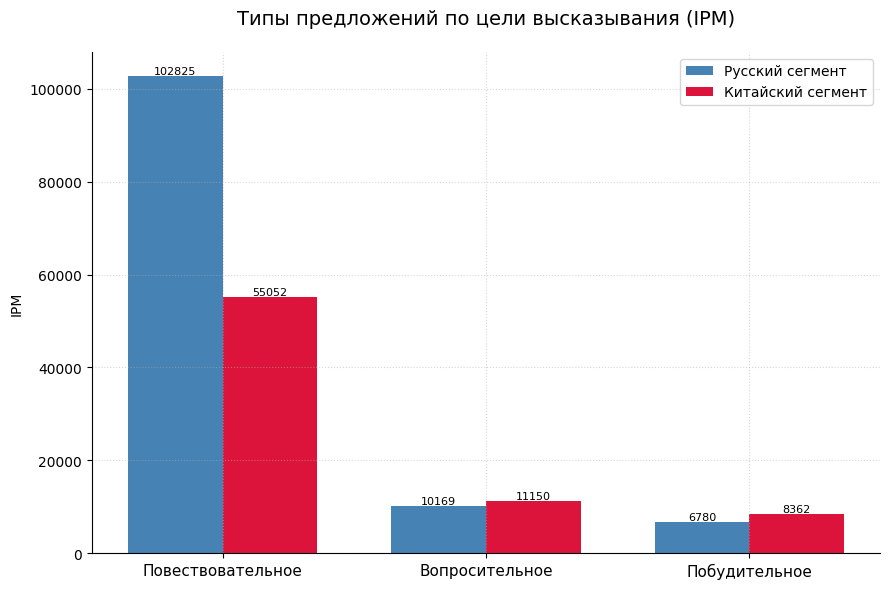

In [198]:
goal_labels = ['Повествовательное','Вопросительное','Побудительное']
fig, ax = plt.subplots(figsize=(9, 6)); x = np.arange(3); w = 0.36
b_ru_b = ax.bar(x - w/2, r5g, w, label='Русский сегмент', color=COLORS['RU'])
b_zh_b = ax.bar(x + w/2, c5g, w, label='Китайский сегмент', color=COLORS['ZH'])
add_labels(b_ru_b, ax); add_labels(b_zh_b, ax)
ax.set_title('Типы предложений по цели высказывания (IPM)', pad=20, fontsize=14)
ax.set_ylabel('IPM'); ax.set_xticks(x)
ax.set_xticklabels(goal_labels, fontsize=11); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

In [199]:
b5_expr = [
    'парцелляция\n','сегментация\n','асиндетон\n',
    'синт.\nпараллелизм','риторический\nвопрос',
    '«двойной»\nзаголовок','одинаковый синтаксический рисунок',
    'однородные\nчлены',
]
ft5e = freq_table(df_ru, df_zh, b5_expr)
print('=== 5.3 Конструкции экспрессивного синтаксиса ===')
display(ft5e)

=== 5.3 Конструкции экспрессивного синтаксиса ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,парцелляция,0,0.0,0.0,0,0.0,0.0
1,сегментация,3,3.0,3389.8,11,11.0,7665.5
2,асиндетон,4,4.0,4519.8,1,1.0,696.9
3,синт. параллелизм,0,0.0,0.0,4,4.0,2787.5
4,риторический вопрос,4,4.0,4519.8,3,3.0,2090.6
5,«двойной» заголовок,4,4.0,4519.8,0,0.0,0.0
6,одинаковый синтаксический рисунок,0,0.0,0.0,3,3.0,2090.6
7,однородные члены,24,24.0,27118.6,13,13.0,9059.2


In [200]:
r5e, c5e = ipm_vectors(df_ru, df_zh, b5_expr)
spearman_block(r5e, c5e, 'Блок 5.3 Конструкции экспрессивного синтаксиса')
mannwhitney_block(df_ru, df_zh, b5_expr, 'Блок 5.3 Конструкции экспрессивного синтаксиса');

Спирмен [Блок 5.3 Конструкции экспрессивного синтаксиса]:  r = 0.203,  p = 0.6303  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 5.3 Конструкции экспрессивного синтаксиса ───


,Признак,U,p-value (raw),Значимость
0,сегментация,4616.000000,0.034133,**p < 0.05**
1,асиндетон,5150.500000,0.175354,p ≥ 0.05
2,синт. параллелизм,4800.000000,0.044421,**p < 0.05**
3,риторический вопрос,5053.500000,0.684199,p ≥ 0.05
4,«двойной» заголовок,5200.000000,0.044423,**p < 0.05**
5,одинаковый синтаксический рисунок,4850.000000,0.082745,p ≥ 0.05
6,однородные члены,5639.000000,0.021238,**p < 0.05**


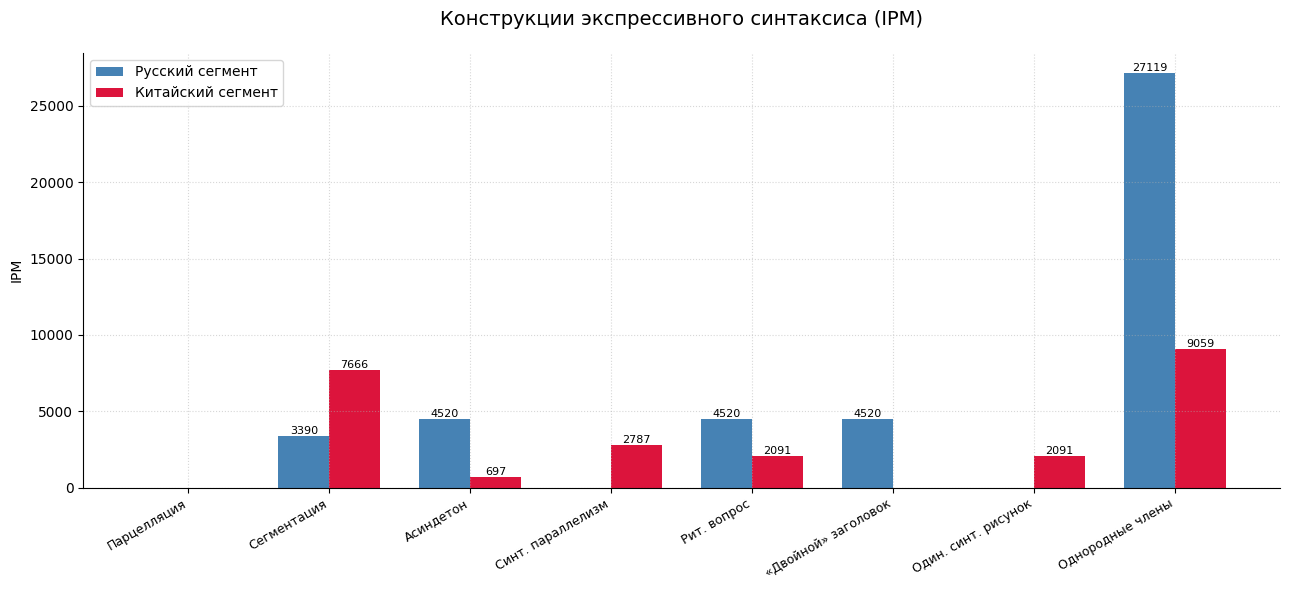

In [201]:
expr_labels = ['Парцелляция','Сегментация','Асиндетон','Синт. параллелизм',
               'Рит. вопрос','«Двойной» заголовок','Один. синт. рисунок','Однородные члены']
fig, ax = plt.subplots(figsize=(13, 6)); x = np.arange(len(expr_labels)); w = 0.36
b_ru_b = ax.bar(x - w/2, r5e, w, label='Русский сегмент', color=COLORS['RU'])
b_zh_b = ax.bar(x + w/2, c5e, w, label='Китайский сегмент', color=COLORS['ZH'])
add_labels(b_ru_b, ax); add_labels(b_zh_b, ax)
ax.set_title('Конструкции экспрессивного синтаксиса (IPM)', pad=20, fontsize=14)
ax.set_ylabel('IPM'); ax.set_xticks(x)
ax.set_xticklabels(expr_labels, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

---
## Блок 6. Прагматический уровень

In [202]:
b6_strat = [
    'привлечение\nвнимания','провокация','самопрезен-\nтация',
    'адресация\nчитателя','информирование','оценочность',
    'побуждение\nк действию',
]
ft6s = freq_table(df_ru, df_zh, b6_strat)
print('=== 6.1 Коммуникативная стратегия ===')
display(ft6s)

=== 6.1 Коммуникативная стратегия ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,привлечение внимания,68,68.0,76836.2,77,77.0,53658.5
1,провокация,7,7.0,7909.6,8,8.0,5574.9
2,самопрезен- тация,5,5.0,5649.7,29,29.0,20209.1
3,адресация читателя,14,14.0,15819.2,27,27.0,18815.3
4,информирование,86,86.0,97175.1,67,67.0,46689.9
5,оценочность,23,23.0,25988.7,52,52.0,36236.9
6,побуждение к действию,9,9.0,10169.5,23,23.0,16027.9


In [203]:
r6s, c6s = ipm_vectors(df_ru, df_zh, b6_strat)
spearman_block(r6s, c6s, 'Блок 6.1 Коммуникативная стратегия')
mannwhitney_block(df_ru, df_zh, b6_strat, 'Блок 6.1 Коммуникативная стратегия');

Спирмен [Блок 6.1 Коммуникативная стратегия]:  r = 0.750,  p = 0.0522  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 6.1 Коммуникативная стратегия ───


,Признак,U,p-value (raw),Значимость
0,привлечение внимания,6304.500000,0.001270,**p < 0.05**
1,провокация,4964.000000,0.849353,p ≥ 0.05
2,самопрезен- тация,3833.000000,0.000013,**p < 0.05**
3,адресация читателя,4493.500000,0.079597,p ≥ 0.05
4,информирование,8053.000000,0.000000,**p < 0.05**
5,оценочность,4025.000000,0.006153,**p < 0.05**
6,побуждение к действию,4376.500000,0.017064,**p < 0.05**


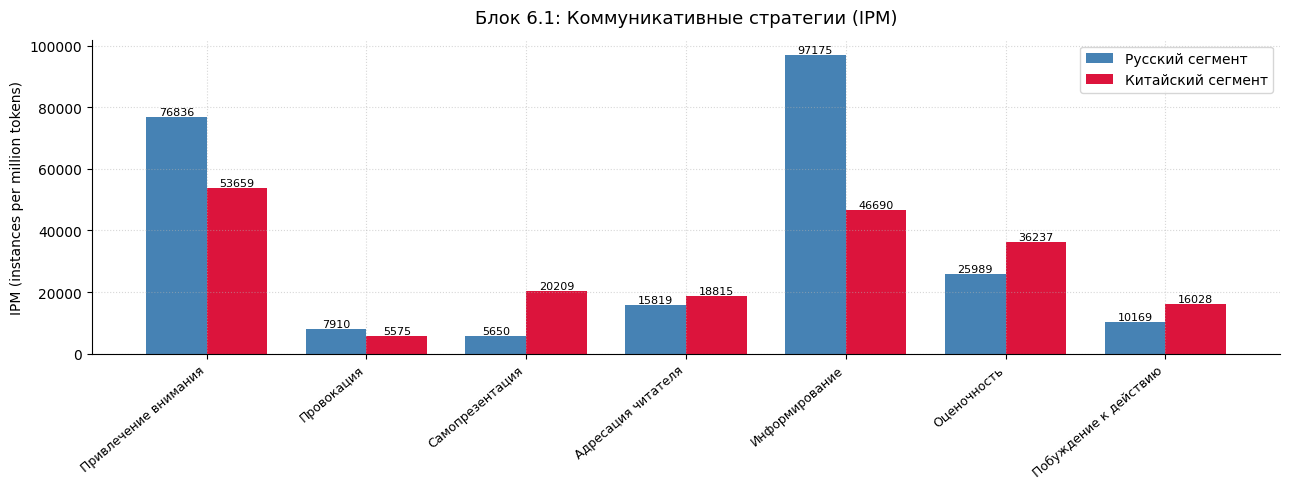

In [204]:
strat_labels = ['Привлечение\nвнимания','Провокация','Самопрезентация',
                'Адресация\nчитателя','Информирование','Оценочность',
                'Побуждение\nк действию']
bar_chart(r6s, c6s, strat_labels, 'Блок 6.1: Коммуникативные стратегии (IPM)')

In [205]:
b6_pers  = ['личное\nобращение','1 л. автора\n']
b6_inter = [
    'прецендентная ситуация','прецедентный\nтекст ',
    'прецедентное\nимя ','прецендентное высказывание',
]
b6_all = b6_pers + b6_inter
ft6pi = freq_table(df_ru, df_zh, b6_all)
print('=== 6.2–6.3 Персонализация и интертекстуальность ===')
display(ft6pi)

=== 6.2–6.3 Персонализация и интертекстуальность ===


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,личное обращение,2,2.0,2259.9,11,11.0,7665.5
1,1 л. автора,6,6.0,6779.7,13,13.0,9059.2
2,прецендентная ситуация,0,0.0,0.0,2,2.0,1393.7
3,прецедентный текст,1,1.0,1129.9,0,0.0,0.0
4,прецедентное имя,7,7.0,7909.6,7,7.0,4878.0
5,прецендентное высказывание,0,0.0,0.0,0,0.0,0.0


In [206]:
r6pi, c6pi = ipm_vectors(df_ru, df_zh, b6_all)
spearman_block(r6pi, c6pi, 'Блок 6.2–6.3 Персонализация + Интертекстуальность')
mannwhitney_block(df_ru, df_zh, b6_all, 'Блок 6.2–6.3 Персонализация + Интертекстуальность');

Спирмен [Блок 6.2–6.3 Персонализация + Интертекстуальность]:  r = 0.691,  p = 0.1283  → ✗ незначима

─── U-критерий Манна–Уитни: Блок 6.2–6.3 Персонализация + Интертекстуальность ───


,Признак,U,p-value (raw),Значимость
0,личное обращение,4561.000000,0.012162,**p < 0.05**
1,1 л. автора,4660.000000,0.102960,p ≥ 0.05
2,прецендентная ситуация,4900.000000,0.158341,p ≥ 0.05
3,прецедентный текст,5050.000000,0.322174,p ≥ 0.05
4,прецедентное имя,5018.500000,0.920793,p ≥ 0.05


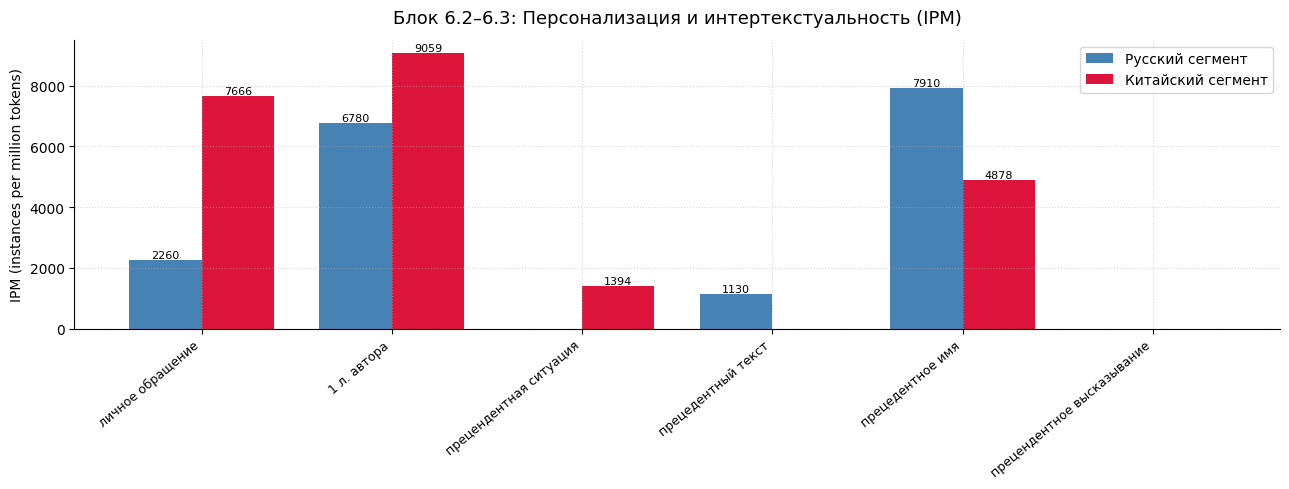

In [207]:
bar_chart(r6pi, c6pi, b6_all, 'Блок 6.2–6.3: Персонализация и интертекстуальность (IPM)')

---
## Сводная таблица всех признаков (IPM)

In [208]:
all_features = (
    b1_graphic + b1_punct + b1_emoji + b1_codes +
    b2 + b3_morph + b4_style + b4_borr + b4_eval + b4_add +
    b5_struct + b5_goal + b5_expr + b6_strat + b6_pers + b6_inter
)

print(f'Всего признаков в анализе: {len(all_features)}')
ft_all = freq_table(df_ru, df_zh, all_features)
display(ft_all.style
        .bar(subset=['IPM RU'], color='#4682B4', vmin=0)
        .bar(subset=['IPM ZH'], color='#DC143C', vmin=0)
        .format({'IPM RU':'{:.1f}','IPM ZH':'{:.1f}',
                 'Отн. RU, %':'{:.1f}','Отн. ZH, %':'{:.1f}'}))

Всего признаков в анализе: 88


,Признак,Абс. RU,"Отн. RU, %",IPM RU,Абс. ZH,"Отн. ZH, %",IPM ZH
0,повтор букв,0,0.0,0.0,0,0.0,0.0
1,сочетание строчных и прописных букв,6,6.0,6779.7,3,3.0,2090.6
2,капитализация текста,2,2.0,2259.9,7,7.0,4878.0
3,наличие восклицательных знаков,7,7.0,7909.6,28,28.0,19512.2
4,повтор восклицательных знаков,0,0.0,0.0,9,9.0,6271.8
5,наличие вопросительных знаков,9,9.0,10169.5,8,8.0,5574.9
6,повтор вопросительных знаков,0,0.0,0.0,0,0.0,0.0
7,многоточие,0,0.0,0.0,2,2.0,1393.7
8,наличие эмодзи,28,28.0,31638.4,47,47.0,32752.6
9,номинативная функция,7,7.0,7909.6,11,11.0,7665.5


---
## Корреляция Спирмена по блокам (сводка)

,Блок,r,p-value,Значимость
0,1.1–1.2 Графика+Пункт.,0.600000,0.116100,✗
1,1.3 Эмотиконы,0.830000,0.010700,✓
2,1.4–1.5 Смешение кодов,0.466000,0.127100,✗
3,2. Фонетика,nan,nan,✗
4,3. Морфология (формы),0.564000,0.321700,✗
5,4.1 Стиль. лексика,0.771000,0.072400,✗
6,4.2 Заимствования,0.778000,0.068700,✗
7,4.3 Оценочность,0.883000,0.008500,✓
8,4.4 Доп. лексика,1.000000,nan,✗
9,5.1 Тип по структуре,0.771000,0.072400,✗



Общая корреляция Спирмена (все признаки, IPM): r = 0.665,  p = 0.0000


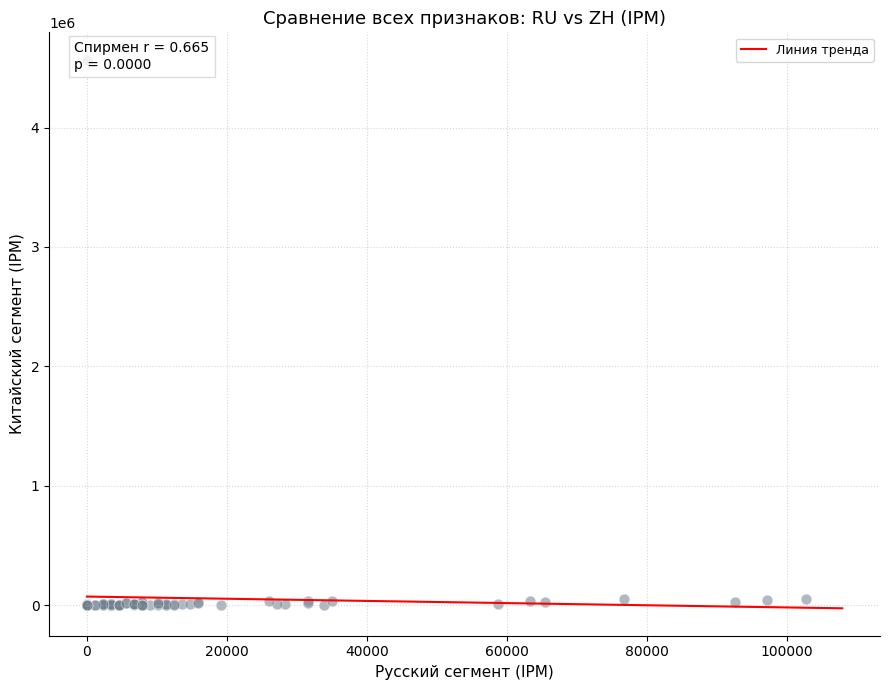

In [209]:
block_data = {
    '1.1–1.2 Графика+Пункт.':   ipm_vectors(df_ru, df_zh, b1_all),
    '1.3 Эмотиконы':             ipm_vectors(df_ru, df_zh, b1_emoji),
    '1.4–1.5 Смешение кодов':    ipm_vectors(df_ru, df_zh, b1_codes),
    '2. Фонетика':                ipm_vectors(df_ru, df_zh, b2),
    '3. Морфология (формы)':      ipm_vectors(df_ru, df_zh, b3_morph),
    '4.1 Стиль. лексика':         ipm_vectors(df_ru, df_zh, b4_style),
    '4.2 Заимствования':          ipm_vectors(df_ru, df_zh, b4_borr),
    '4.3 Оценочность':            ipm_vectors(df_ru, df_zh, b4_eval),
    '4.4 Доп. лексика':           ipm_vectors(df_ru, df_zh, b4_add),
    '5.1 Тип по структуре':       ipm_vectors(df_ru, df_zh, b5_struct),
    '5.2 Тип по цели':            ipm_vectors(df_ru, df_zh, b5_goal),
    '5.3 Экспресс. синтаксис':    ipm_vectors(df_ru, df_zh, b5_expr),
    '6.1 Коммун. стратегия':      ipm_vectors(df_ru, df_zh, b6_strat),
    '6.2–6.3 Персон.+Интертекст': ipm_vectors(df_ru, df_zh, b6_all),
}

summary_rows = []
for block, (rv, cv) in block_data.items():
    corr, p = spearmanr(rv, cv)
    summary_rows.append({'Блок': block, 'r': round(corr, 3),
                         'p-value': round(p, 4),
                         'Значимость': '✓' if p < 0.05 else '✗'})
spearman_df = pd.DataFrame(summary_rows)
display(spearman_df.style.applymap(
    lambda v: 'color:green; font-weight:bold' if v == '✓' else
              ('color:gray' if v == '✗' else ''),
    subset=['Значимость']))

# Общий scatter по всем признакам
r_all_ipm, c_all_ipm = ipm_vectors(df_ru, df_zh, all_features)
corr_all, p_all = spearmanr(r_all_ipm, c_all_ipm)
print(f'\nОбщая корреляция Спирмена (все признаки, IPM): r = {corr_all:.3f},  p = {p_all:.4f}')

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(r_all_ipm, c_all_ipm, alpha=0.55, s=60,
           color='slategray', edgecolors='white', linewidths=0.5)
if len(set(r_all_ipm)) > 1:
    m, b_c = np.polyfit(r_all_ipm, c_all_ipm, 1)
    xl = np.linspace(0, r_all_ipm.max()*1.05, 200)
    ax.plot(xl, m*xl + b_c, color='red', lw=1.5, label='Линия тренда')
ax.set_xlabel('Русский сегмент (IPM)', fontsize=11)
ax.set_ylabel('Китайский сегмент (IPM)', fontsize=11)
ax.set_title('Сравнение всех признаков: RU vs ZH (IPM)', fontsize=13)
ax.text(0.03, 0.94, f'Спирмен r = {corr_all:.3f}\np = {p_all:.4f}',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', edgecolor='lightgray', alpha=0.8), fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## Поправка на множественное сравнение: Беньямини–Хохберг (FDR)
Все p-значения из тестов Манна–Уитни по **всем блокам** корректируются совместно.  
Порог FDR = 5% (q = 0.05). **p_adj** — скорректированное p-значение (BH).

In [210]:
if not ALL_MW_RESULTS:
    print('⚠ Список ALL_MW_RESULTS пуст — запустите ячейки с тестами выше.')
else:
    bh_df = pd.DataFrame(ALL_MW_RESULTS).copy()
    raw_pvals = bh_df['p-value (raw)'].values
    reject, pvals_adj, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')
    bh_df['p_adj (BH)']   = np.round(pvals_adj, 6)
    bh_df['Значимо (BH)'] = reject
    bh_df['Значимость']   = bh_df['p_adj (BH)'].apply(
        lambda v: '✓ p_adj < 0.05' if v < 0.05 else '✗ p_adj ≥ 0.05')

    n_raw_sig = int((bh_df['p-value (raw)'] < 0.05).sum())
    n_bh_sig  = int(bh_df['Значимо (BH)'].sum())
    print(f'Всего тестов: {len(bh_df)}')
    print(f'Значимых до поправки  (p < 0.05):      {n_raw_sig}')
    print(f'Значимых после поправки BH (q < 0.05): {n_bh_sig}')
    print()

    display_df = bh_df[['Блок','Признак','U','p-value (raw)','p_adj (BH)','Значимость']] \
                 .sort_values('p_adj (BH)')
    display(display_df.style
        .applymap(
            lambda v: 'font-weight:bold; color:darkgreen' if '✓' in str(v) else
                      ('color:gray' if '✗' in str(v) else ''),
            subset=['Значимость'])
        .format({'p-value (raw)':'{:.5f}','p_adj (BH)':'{:.5f}','U':'{:.1f}'})
        .background_gradient(subset=['p_adj (BH)'], cmap='RdYlGn_r', vmin=0, vmax=0.1))

Всего тестов: 76
Значимых до поправки  (p < 0.05):      34
Значимых после поправки BH (q < 0.05): 24



,Блок,Признак,U,p-value (raw),p_adj (BH),Значимость
24,Блок 3 Морфология (формы),модель: имя прилагательное + имя существительное,7060.5,0.00000,0.00000,✓ p_adj < 0.05
29,Блок 4.1 Стилистически маркированная лексика,нейтральная лексика,8254.5,0.00000,0.00000,✓ p_adj < 0.05
54,Блок 5.2 Тип предложения по цели,повествовательное .,7965.5,0.00000,0.00000,✓ p_adj < 0.05
52,Блок 5.1 Тип предложения по структуре,номинативное,6897.0,0.00000,0.00000,✓ p_adj < 0.05
68,Блок 6.1 Коммуникативная стратегия,информирование,8053.0,0.00000,0.00000,✓ p_adj < 0.05
31,Блок 4.1 Стилистически маркированная лексика,интернет-сленг,3754.5,0.00001,0.00008,✓ p_adj < 0.05
53,Блок 5.1 Тип предложения по структуре,неполное,3746.0,0.00001,0.00011,✓ p_adj < 0.05
35,Блок 4.2 Заимствования,англицизм,6214.0,0.00001,0.00011,✓ p_adj < 0.05
66,Блок 6.1 Коммуникативная стратегия,самопрезен- тация,3833.0,0.00001,0.00011,✓ p_adj < 0.05
50,Блок 5.1 Тип предложения по структуре,СПП,5808.5,0.00007,0.00053,✓ p_adj < 0.05


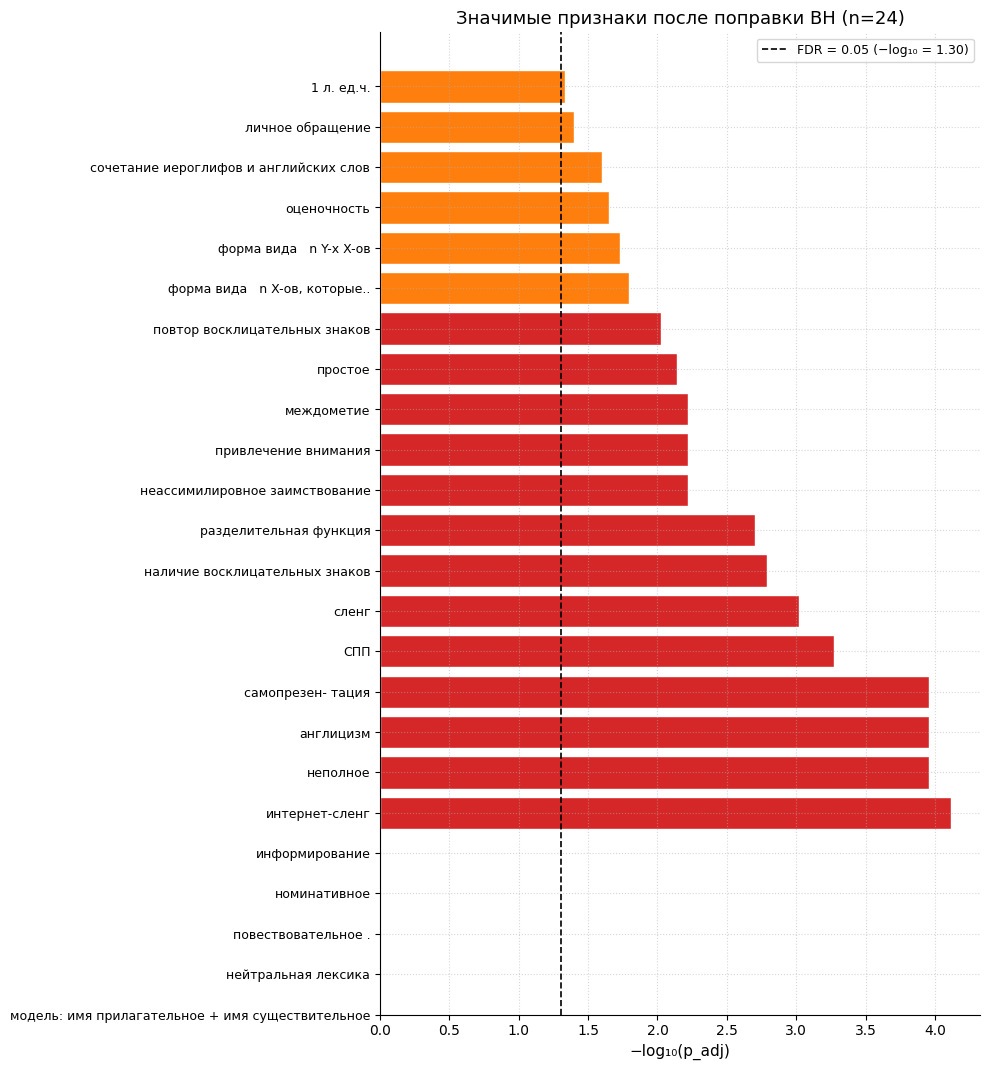


=== Значимые признаки (p_adj < 0.05) ===


,Блок,Признак,p-value (raw),p_adj (BH)
0,Блок 3 Морфология (формы),модель: имя прилагательное + имя существительное,0.000000,0.000000
1,Блок 4.1 Стилистически маркированная лексика,нейтральная лексика,0.000000,0.000000
2,Блок 5.2 Тип предложения по цели,повествовательное .,0.000000,0.000000
3,Блок 5.1 Тип предложения по структуре,номинативное,0.000000,0.000000
4,Блок 6.1 Коммуникативная стратегия,информирование,0.000000,0.000000
5,Блок 4.1 Стилистически маркированная лексика,интернет-сленг,0.000006,0.000076
6,Блок 5.1 Тип предложения по структуре,неполное,0.000012,0.000110
7,Блок 4.2 Заимствования,англицизм,0.000012,0.000110
8,Блок 6.1 Коммуникативная стратегия,самопрезен- тация,0.000013,0.000110
9,Блок 5.1 Тип предложения по структуре,СПП,0.000070,0.000532


In [211]:
if ALL_MW_RESULTS:
    sig_bh = bh_df[bh_df['Значимо (BH)']].sort_values('p_adj (BH)')
    if sig_bh.empty:
        print('После поправки BH значимых признаков не осталось.')
    else:
        fig, ax = plt.subplots(figsize=(10, max(4, len(sig_bh) * 0.45)))
        y = np.arange(len(sig_bh))
        clrs = ['#d62728' if p < 0.01 else '#ff7f0e' for p in sig_bh['p_adj (BH)']]
        ax.barh(y, -np.log10(sig_bh['p_adj (BH)']), color=clrs, edgecolor='white')
        ax.axvline(-np.log10(0.05), color='black', linestyle='--', lw=1.2,
                   label='FDR = 0.05 (−log₁₀ = 1.30)')
        ax.set_yticks(y)
        ax.set_yticklabels(sig_bh['Признак'], fontsize=9)
        ax.set_xlabel('−log₁₀(p_adj)', fontsize=11)
        ax.set_title(f'Значимые признаки после поправки BH (n={len(sig_bh)})', fontsize=13)
        ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()

        print('\n=== Значимые признаки (p_adj < 0.05) ===')
        display(sig_bh[['Блок','Признак','p-value (raw)','p_adj (BH)']].reset_index(drop=True))

---
## Scatter-plots корреляции по блокам (IPM)

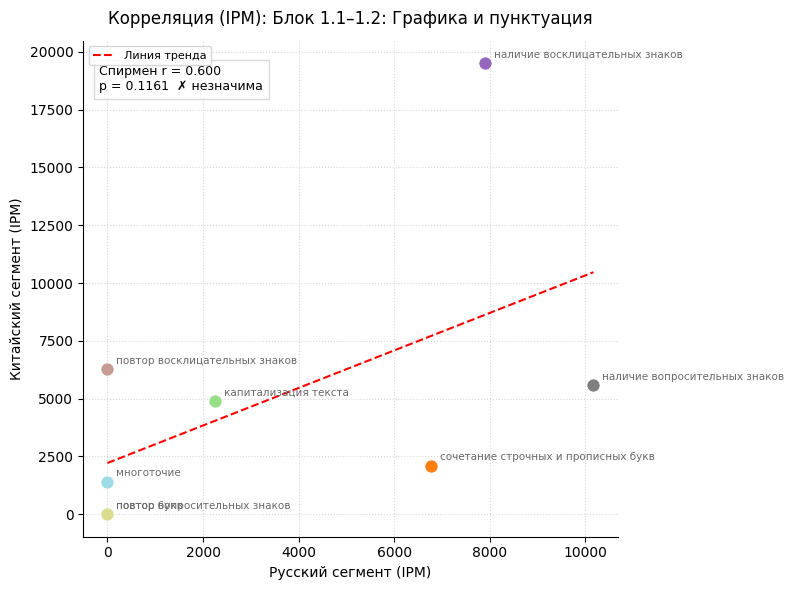

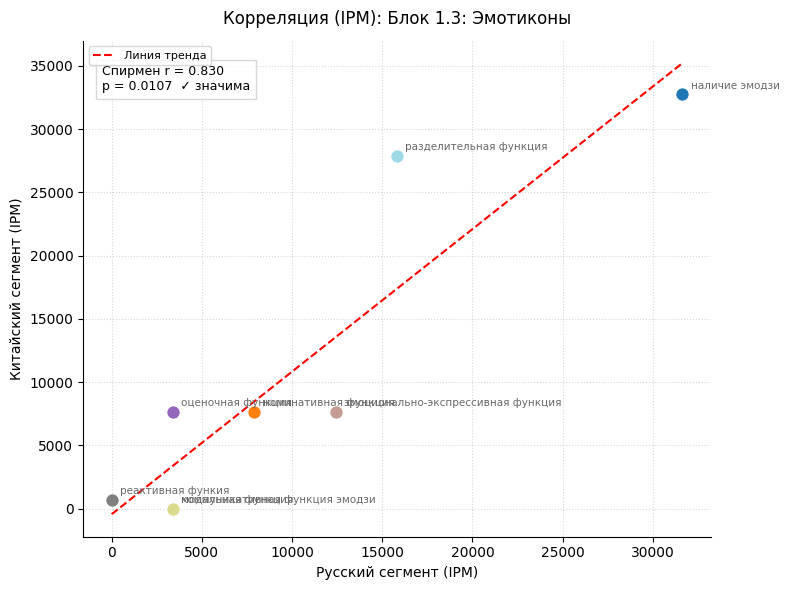

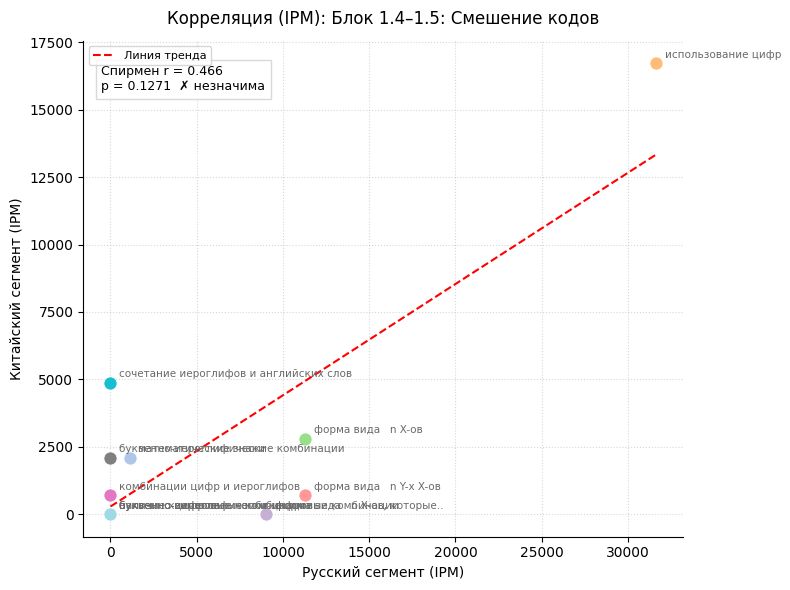

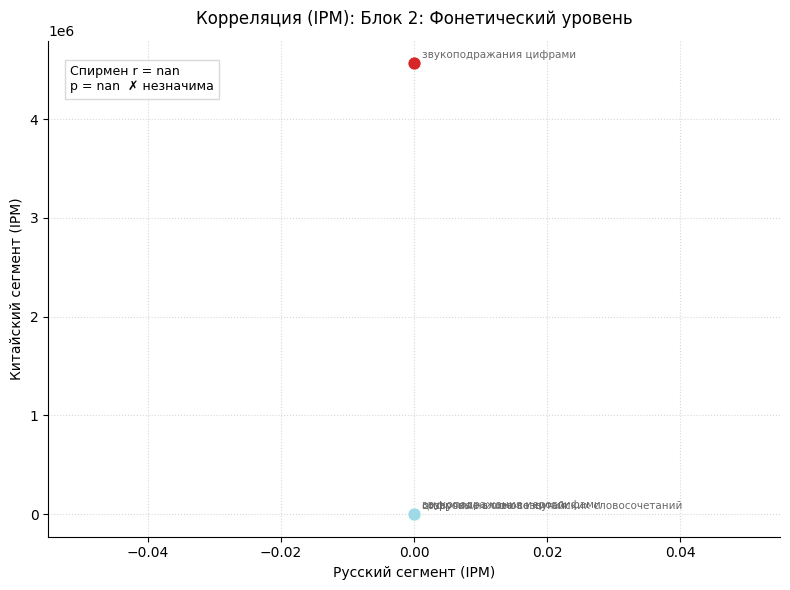

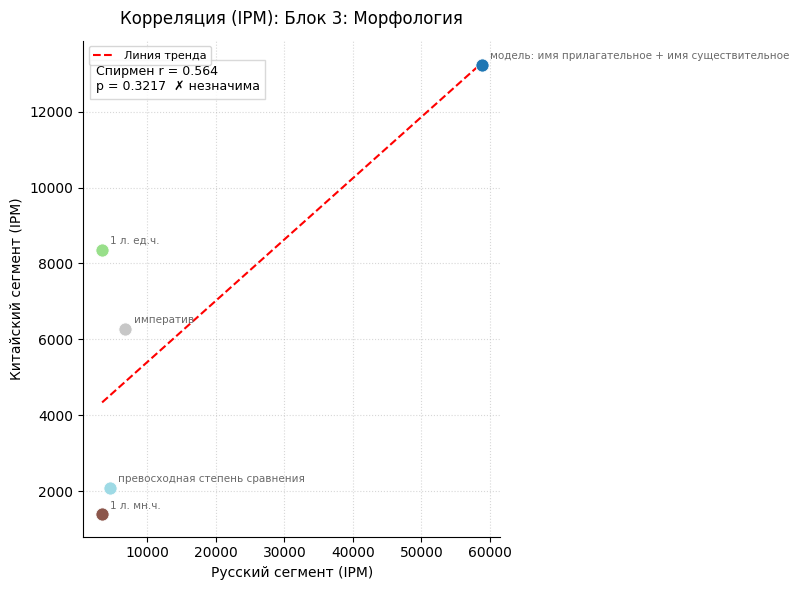

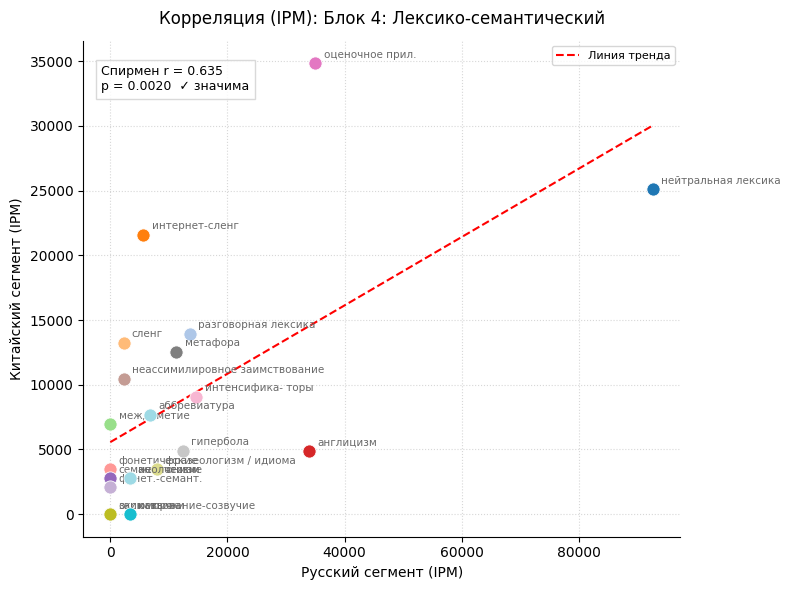

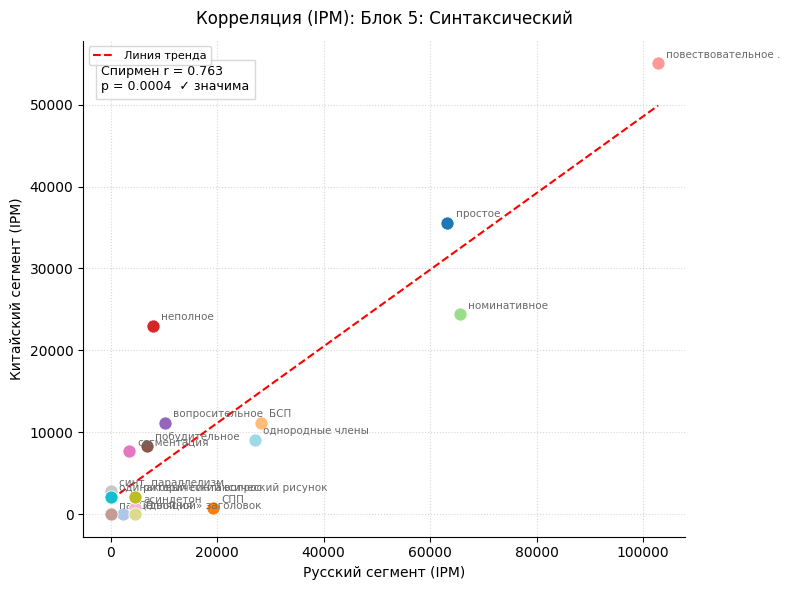

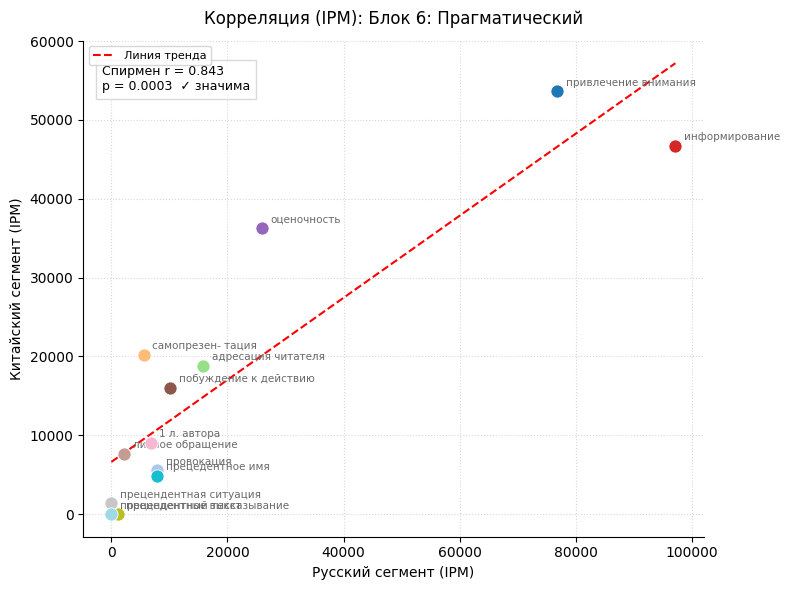

In [212]:
for block_name, cols in [
    ('Блок 1.1–1.2: Графика и пунктуация', b1_all),
    ('Блок 1.3: Эмотиконы', b1_emoji),
    ('Блок 1.4–1.5: Смешение кодов', b1_codes),
    ('Блок 2: Фонетический уровень', b2),
    ('Блок 3: Морфология', b3_morph),
    ('Блок 4: Лексико-семантический', b4_style + b4_borr + b4_eval + b4_add),
    ('Блок 5: Синтаксический', b5_struct + b5_goal + b5_expr),
    ('Блок 6: Прагматический', b6_strat + b6_all),
]:
    plot_block_scatter(*ipm_vectors(df_ru, df_zh, cols),
                       [c.replace('\n',' ').strip() for c in cols],
                       block_name)